# Relationship Score Analysis - Exploratory Data Analysis

## Purpose
This notebook performs comprehensive EDA to understand and predict relationship strength between company and customers based on:
- Interaction frequency and recency
- Sentiment and engagement metrics
- Contract duration and history
- Support interactions
- Communication patterns
- Account health indicators

## Key Metrics Analyzed
- **Relationship Score** - Current relationship strength (0-100)
- **Interaction Frequency** - Contact frequency patterns
- **Sentiment Analysis** - Customer sentiment impact on relationship
- **Engagement Metrics** - Response rates and engagement levels
- **Contract Maturity** - Relationship duration and stability
- **Support Quality** - Support interaction patterns
- **Relationship Trends** - Improving, stable, or declining relationships

In [4]:
# Install required packages
!uv add pandas numpy matplotlib seaborn openpyxl scikit-learn

Resolved 54 packages in 2ms
Audited 47 packages in 11ms


In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Explore Data

In [6]:
# Load the dataset
# Try multiple possible paths
possible_paths = [
    Path("../../customer_data_25000.xlsx"),
    Path("../customer_data_25000.xlsx"),
    Path("customer_data_25000.xlsx"),
    Path("D:/Internship/Renewal-Upsell-Advisor/Research/customer_data_25000.xlsx")
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Could not find customer_data_25000.xlsx. Please check the file path.")

df = pd.read_excel(data_path, sheet_name="Accounts")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: 24,874 rows × 27 columns

Column Names:
   1. name
   2. domain
   3. industry
   4. company_size
   5. arr
   6. mrr
   7. contract_start_date
   8. contract_end_date
   9. renewal_date
  10. last_contact_date
  11. status
  12. renewal_stage
  13. health_score
  14. risk_score
  15. relationship_score
  16. churn_probability
  17. sentiment_score
  18. sentiment_category
  19. licenses_total
  20. licenses_used
  21. utilization_percentage
  22. csm_name
  23. csm_email
  24. primary_contact_name
  25. primary_contact_email
  26. primary_contact_phone
  27. salesforce_id

First few rows:


,name,domain,industry,company_size,arr,mrr,contract_start_date,contract_end_date,renewal_date,last_contact_date,...,sentiment_category,licenses_total,licenses_used,utilization_percentage,csm_name,csm_email,primary_contact_name,primary_contact_email,primary_contact_phone,salesforce_id
0,Cole LLC,colellc.com,Technology,Small,156049,13004.08,2025-06-05,2026-06-05,2026-06-05,2026-02-13 16:43:27,...,neutral,20,15,79,Sarah Chen,sarah.chen@company.com,Danielle Johnson,john21@example.net,001-581-896-0013x3890,NaN
1,"Stevens, Martinez and Nielsen",stevensmartinezandnielsen.com,Healthcare,Medium,517493,43124.42,2025-05-19,2026-05-19,2026-05-19,2026-02-04 16:43:27,...,positive,30,23,79,Maria Lopez,maria.lopez@company.com,Lisa Smith,helenpeterson@example.org,651.216.1559,NaN
2,Clark-Adams,clark-adams.com,Analytics,Large,64898,5408.17,2025-04-28,2026-04-28,2026-04-28,2026-02-12 16:43:27,...,negative,20,14,73,Emily Rodriguez,emily.rodriguez@company.com,Christian Carter,barbara10@example.net,441.731.6475,SF-748564
3,"Porter, Wilkerson and Day",porterwilkersonandday.com,Healthcare,Medium,43003,3583.58,2025-05-01,2026-05-01,2026-05-01,2026-02-06 16:43:27,...,neutral,20,14,73,David Kim,david.kim@company.com,Sharon Wong,amandasanchez@example.com,(748)535-0305x6413,SF-319684
4,Carlson-Mcdonald,carlson-mcdonald.com,Enterprise,Medium,100005,8333.75,2025-06-09,2026-06-09,2026-06-09,2026-01-19 16:43:27,...,very_positive,50,33,66,Sarah Chen,sarah.chen@company.com,Douglas Taylor,julie69@example.com,(332)887-1012x269,SF-944151


In [7]:
# Basic information about the dataset
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(f"\nTotal Records: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")

print(f"\nMissing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

print(f"\nBasic Statistics for Relationship-Related Features:")
relationship_features = ['relationship_score', 'sentiment_score', 'health_score', 
                        'risk_score', 'churn_probability', 'arr', 'mrr']
available_features = [f for f in relationship_features if f in df.columns]
if available_features:
    print(df[available_features].describe())

DATASET INFORMATION

Total Records: 24,874
Total Columns: 27

Missing Values:
               Missing Count  Missing Percentage
salesforce_id           7501           30.155986

Basic Statistics for Relationship-Related Features:
       relationship_score  sentiment_score  health_score    risk_score  \
count        24874.000000     24874.000000  24874.000000  24874.000000   
mean            68.826727         0.390492     70.217778     40.251628   
std             19.149438         0.438628     17.780470     21.742285   
min             25.000000        -0.999400     30.000000      5.000000   
25%             56.000000         0.098725     58.000000     23.000000   
50%             72.000000         0.477550     72.000000     37.000000   
75%             83.000000         0.738200     83.000000     55.000000   
max            100.000000         0.999900    100.000000     90.000000   

       churn_probability            arr           mrr  
count       24874.000000   24874.000000  24874.0

## 2. Feature Engineering for Relationship Analysis

In [8]:
# Create a copy for relationship analysis
df_relationship = df.copy()

# Convert date columns to datetime
date_columns = ['contract_start_date', 'contract_end_date', 'renewal_date', 'last_contact_date']
for col in date_columns:
    if col in df_relationship.columns:
        df_relationship[col] = pd.to_datetime(df_relationship[col], errors='coerce')

# Calculate days since last contact (interaction recency)
if 'last_contact_date' in df_relationship.columns:
    today = pd.Timestamp.now()
    df_relationship['days_since_last_contact'] = (today - df_relationship['last_contact_date']).dt.days
    print(f"Calculated days_since_last_contact")
    print(f"  Min: {df_relationship['days_since_last_contact'].min():.0f} days")
    print(f"  Max: {df_relationship['days_since_last_contact'].max():.0f} days")
    print(f"  Mean: {df_relationship['days_since_last_contact'].mean():.2f} days")

# Calculate contract duration in months (relationship length)
if 'contract_start_date' in df_relationship.columns and 'contract_end_date' in df_relationship.columns:
    if 'contract_duration_months' not in df_relationship.columns:
        df_relationship['contract_duration_months'] = (
            (df_relationship['contract_end_date'] - df_relationship['contract_start_date']).dt.days / 30.44
        ).round(1)
        print(f"\nCalculated contract_duration_months")
        print(f"  Min: {df_relationship['contract_duration_months'].min():.1f} months")
        print(f"  Max: {df_relationship['contract_duration_months'].max():.1f} months")
        print(f"  Mean: {df_relationship['contract_duration_months'].mean():.2f} months")

# Calculate relationship age (months since contract start)
if 'contract_start_date' in df_relationship.columns:
    today = pd.Timestamp.now()
    df_relationship['relationship_age_months'] = (
        (today - df_relationship['contract_start_date']).dt.days / 30.44
    ).round(1)
    df_relationship['relationship_age_months'] = df_relationship['relationship_age_months'].clip(lower=0)
    print(f"\nCalculated relationship_age_months")
    print(f"  Mean: {df_relationship['relationship_age_months'].mean():.2f} months")

# Create interaction frequency categories based on days_since_last_contact
if 'days_since_last_contact' in df_relationship.columns:
    def categorize_interaction_frequency(days):
        if pd.isna(days):
            return 'unknown'
        elif days <= 7:
            return 'very_frequent'  # Weekly or more
        elif days <= 30:
            return 'frequent'  # Monthly
        elif days <= 90:
            return 'moderate'  # Quarterly
        elif days <= 180:
            return 'infrequent'  # Semi-annually
        else:
            return 'rare'  # Rarely
    
    df_relationship['interaction_frequency'] = df_relationship['days_since_last_contact'].apply(
        categorize_interaction_frequency
    )
    print(f"\nInteraction Frequency Distribution:")
    print(df_relationship['interaction_frequency'].value_counts())

# Create relationship score categories
if 'relationship_score' in df_relationship.columns:
    def categorize_relationship_score(score):
        if pd.isna(score):
            return 'unknown'
        elif score >= 80:
            return 'excellent'
        elif score >= 65:
            return 'good'
        elif score >= 50:
            return 'fair'
        elif score >= 35:
            return 'poor'
        else:
            return 'critical'
    
    df_relationship['relationship_category'] = df_relationship['relationship_score'].apply(
        categorize_relationship_score
    )
    print(f"\nRelationship Score Categories:")
    print(df_relationship['relationship_category'].value_counts())

# Calculate engagement score (composite of sentiment and interaction)
if 'sentiment_score' in df_relationship.columns and 'days_since_last_contact' in df_relationship.columns:
    # Normalize sentiment score to 0-1 (assuming it's already in a reasonable range)
    sentiment_norm = (df_relationship['sentiment_score'] - df_relationship['sentiment_score'].min()) / (
        df_relationship['sentiment_score'].max() - df_relationship['sentiment_score'].min() + 1e-6
    )
    
    # Normalize days_since_last_contact (inverse - more recent = higher score)
    max_days = df_relationship['days_since_last_contact'].max()
    recency_norm = 1 - (df_relationship['days_since_last_contact'] / (max_days + 1e-6))
    recency_norm = recency_norm.clip(0, 1)
    
    # Composite engagement score
    df_relationship['engagement_score'] = (sentiment_norm * 0.6 + recency_norm * 0.4) * 100
    print(f"\nCalculated engagement_score")
    print(f"  Mean: {df_relationship['engagement_score'].mean():.2f}")
    print(f"  Min: {df_relationship['engagement_score'].min():.2f}")
    print(f"  Max: {df_relationship['engagement_score'].max():.2f}")

print(f"\n{'='*80}")
print("Feature Engineering Complete!")
print(f"{'='*80}")

Calculated days_since_last_contact
  Min: 0 days
  Max: 30 days
  Mean: 14.96 days

Calculated contract_duration_months
  Min: 12.0 months
  Max: 12.0 months
  Mean: 12.00 months

Calculated relationship_age_months
  Mean: 9.52 months

Interaction Frequency Distribution:
interaction_frequency
frequent         18425
very_frequent     6449
Name: count, dtype: int64

Relationship Score Categories:
relationship_category
excellent    8262
good         7229
fair         5255
poor         2460
critical     1668
Name: count, dtype: int64

Calculated engagement_score
  Mean: 61.76
  Min: 0.20
  Max: 99.99

Feature Engineering Complete!


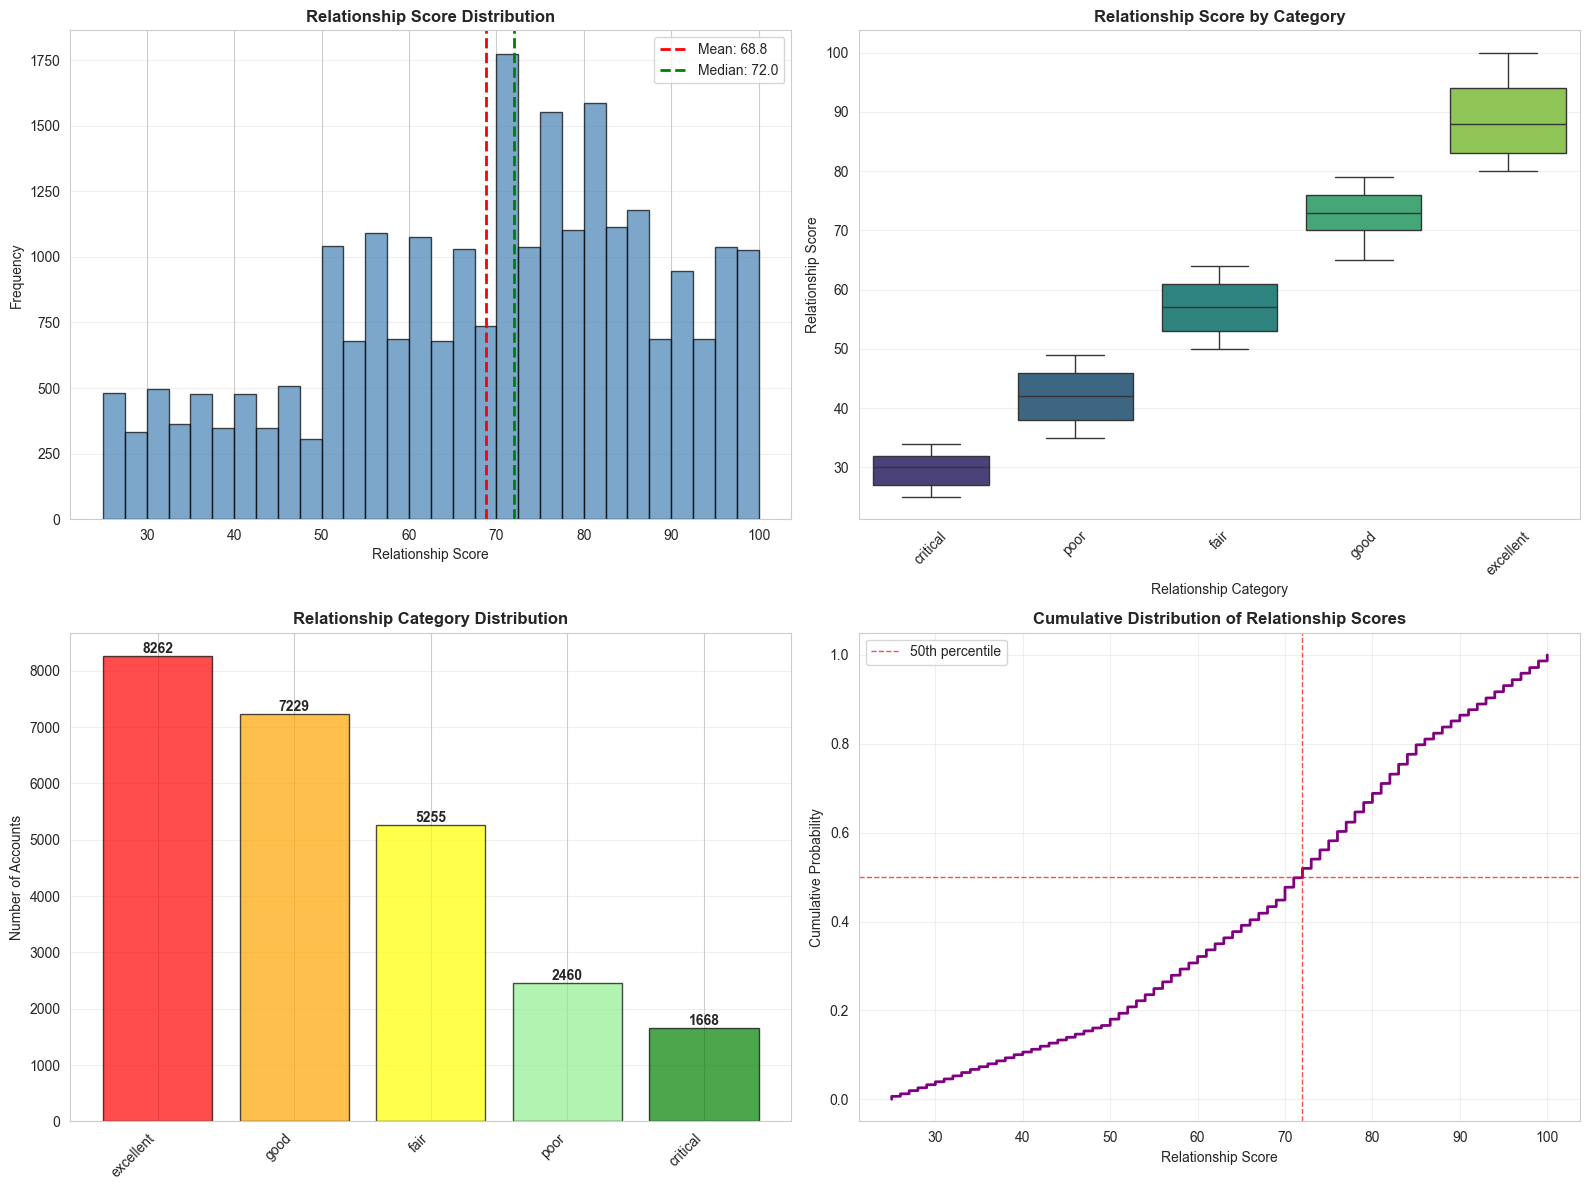

RELATIONSHIP SCORE SUMMARY STATISTICS
Mean: 68.83
Median: 72.00
Std: 19.15
Min: 25.00
Max: 100.00
25th Percentile: 56.00
75th Percentile: 83.00

Relationship Category Breakdown:
                       Count  Mean Score  Std Score
relationship_category                              
critical                1668       29.61       2.87
excellent               8262       88.96       6.26
fair                    5255       57.01       4.30
good                    7229       72.58       4.12
poor                    2460       42.01       4.27


In [9]:
# Analyze relationship score distribution
if 'relationship_score' in df_relationship.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Histogram of relationship scores
    axes[0, 0].hist(df_relationship['relationship_score'].dropna(), bins=30, 
                   color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df_relationship['relationship_score'].mean(), color='red', 
                       linestyle='--', linewidth=2, label=f'Mean: {df_relationship["relationship_score"].mean():.1f}')
    axes[0, 0].axvline(df_relationship['relationship_score'].median(), color='green', 
                      linestyle='--', linewidth=2, label=f'Median: {df_relationship["relationship_score"].median():.1f}')
    axes[0, 0].set_title('Relationship Score Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Relationship Score', fontsize=10)
    axes[0, 0].set_ylabel('Frequency', fontsize=10)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # 2. Box plot by relationship category
    if 'relationship_category' in df_relationship.columns:
        category_order = ['critical', 'poor', 'fair', 'good', 'excellent']
        available_categories = [c for c in category_order if c in df_relationship['relationship_category'].values]
        df_plot = df_relationship[df_relationship['relationship_category'].isin(available_categories)]
        
        sns.boxplot(data=df_plot, x='relationship_category', y='relationship_score', 
                   order=available_categories, ax=axes[0, 1], palette='viridis')
        axes[0, 1].set_title('Relationship Score by Category', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Relationship Category', fontsize=10)
        axes[0, 1].set_ylabel('Relationship Score', fontsize=10)
        axes[0, 1].tick_params(axis='x', rotation=45)
        axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # 3. Relationship category distribution
    if 'relationship_category' in df_relationship.columns:
        cat_counts = df_relationship['relationship_category'].value_counts()
        colors = ['red', 'orange', 'yellow', 'lightgreen', 'green']
        axes[1, 0].bar(range(len(cat_counts)), cat_counts.values, 
                      color=colors[:len(cat_counts)], edgecolor='black', alpha=0.7)
        axes[1, 0].set_xticks(range(len(cat_counts)))
        axes[1, 0].set_xticklabels(cat_counts.index, rotation=45, ha='right')
        axes[1, 0].set_title('Relationship Category Distribution', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Number of Accounts', fontsize=10)
        axes[1, 0].grid(True, alpha=0.3, axis='y')
        for i, v in enumerate(cat_counts.values):
            axes[1, 0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')
    
    # 4. Cumulative distribution
    sorted_scores = np.sort(df_relationship['relationship_score'].dropna())
    cumulative = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
    axes[1, 1].plot(sorted_scores, cumulative, linewidth=2, color='purple')
    axes[1, 1].axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.7, label='50th percentile')
    axes[1, 1].axvline(df_relationship['relationship_score'].median(), color='red', 
                      linestyle='--', linewidth=1, alpha=0.7)
    axes[1, 1].set_title('Cumulative Distribution of Relationship Scores', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Relationship Score', fontsize=10)
    axes[1, 1].set_ylabel('Cumulative Probability', fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("=" * 80)
    print("RELATIONSHIP SCORE SUMMARY STATISTICS")
    print("=" * 80)
    rs = df_relationship['relationship_score']
    print(f"Mean: {rs.mean():.2f}")
    print(f"Median: {rs.median():.2f}")
    print(f"Std: {rs.std():.2f}")
    print(f"Min: {rs.min():.2f}")
    print(f"Max: {rs.max():.2f}")
    print(f"25th Percentile: {rs.quantile(0.25):.2f}")
    print(f"75th Percentile: {rs.quantile(0.75):.2f}")
    
    if 'relationship_category' in df_relationship.columns:
        print(f"\nRelationship Category Breakdown:")
        cat_summary = df_relationship.groupby('relationship_category')['relationship_score'].agg(['count', 'mean', 'std'])
        cat_summary.columns = ['Count', 'Mean Score', 'Std Score']
        print(cat_summary.round(2))